In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<font size = 5, color = 'red'>ch09_Transformers</font>
- 5만개 영화 감상평(독립변수) -> 부정/긍정(타겟변수)
- 구조는 인코딩, 디코딩 형태를 사용하지만 현 부정/긍정의 구조에서는, 즉 입력이 자연어인데 출력이 수치형 데이터라면 디코딩 파트가 필요하지 않음

# 1. 필요 패키지

In [2]:
# 1. 필요 패키지
# 데이터 전처리용
import pandas as pd
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
# 모델 구성용
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, GRU
from time import time # 70.1.1 ~ current millisecond
# 모델 학습 평가용
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

# 2. 하이퍼 파라미터 설정 
-이 파라미터를 바꾸면 정확도나 학습 속도에 차이남

In [3]:
# 2. 하이퍼 파라미터 설정 : 이 파라미터를 바꾸면 정확도나 학습 속도에 차이남
MY_WORDS = 10000 # imdb 데이터의 단어수
MY_LENGTH = 80 # 영화평 단어 수 80개만 독립변수
MY_EMBED = 32 # Embedding 층의 결과 차원(output_dim)
MY_HIDDEN = 64 # LSTM의 유닛수

MY_EPOCH = 10 # 학습 수(fit)
MY_BATCH = 200 # batch_size(fit시 매번 데이터를 가져오는 데이터 크기)

# 3. 데이터 불러오기

In [4]:
# 3. 데이터 불러오기
(x_train,y_train),(x_test,y_test) = imdb.load_data(num_words=MY_WORDS)

In [39]:
print('학습용 입력 변수 모양 :',x_train.shape)
print('학습용 타겟 변수 모양 :',y_train.shape)
print('학습셋 샘플 :',x_train[9000],y_train[5])
print('시험용 입력 변수 모양 :',x_test.shape)
print('시험용 타겟 변수 모양 :',y_test.shape)

학습용 입력 변수 모양 : (25000,)
학습용 타겟 변수 모양 : (25000,)
학습셋 샘플 : [1, 4679, 2784, 2, 11, 27, 217, 17, 1874, 2, 2, 884, 2, 11, 14, 7497, 787, 7, 189, 5, 2, 4, 52, 7412, 3950, 322, 738, 2, 2, 39, 4, 2, 7, 185, 2, 11, 661, 8, 9716, 41, 1940, 5, 936, 51, 128, 273, 18, 4, 1042, 8, 4560, 27, 6281, 74, 33, 4, 6765, 121, 29, 8447, 4, 6259, 7562, 159, 36, 70, 601, 68, 2, 2, 98, 83, 6, 7264, 40, 1110, 29, 961, 98, 8, 27, 3025, 8, 6585, 27, 2, 6636, 1793, 8, 4, 288, 2, 3935, 15, 1420, 2786, 9, 76, 53, 441, 5, 3268, 74, 4, 20, 10, 10, 4, 3586, 2, 8356, 4140, 1675, 4679, 2784, 2, 2, 2870, 2609] 0
시험용 입력 변수 모양 : (25000,)
시험용 타겟 변수 모양 : (25000,)


In [15]:
# 긍정/부정 데이터 비중 정도 체크
print('학습셋의 긍정 개수 :',y_train.sum()) # 12500 -> 비중 반반
print('시험셋의 긍정 개수 :',y_test.sum()) # 12500 -> 비중 반반

학습셋의 긍정 개수 : 12500
시험셋의 긍정 개수 : 12500


# 4. 문자 단어 -> 정수

In [5]:
word_to_id = imdb.get_word_index() # {'word':id}
# print(word_to_id['movie'])
# print(word_to_id.get('film'))
# print(word_to_id.get('sonja'))
# print(word_to_id.get('a'))
# print(word_to_id.get('the'))
# print(word_to_id.get('jong'))
# 정수 -> 문자단어
id_to_word=dict()
for word, idx in word_to_id.items() :
    id_to_word[idx] = word
print(id_to_word[3])

a


In [54]:
msg = "What a wonderful movie"
msg = msg.lower().split()
# 1 : 리뷰 시작을 알리는 숫자, 2 : 문자가 잘려서 잘못 읽어온 결과, 3 : padding처리 
data = [1] + [word_to_id.get(m,-1)+3 for m in msg]
print('원 후기 내용 :',msg)
print('encoded된 data :',data)
print('추정된 data :',' '.join([id_to_word.get(d-3,'???') for d in data]))

원 후기 내용 : ['what', 'a', 'wonderful', 'movie']
encoded된 data : [1, 51, 6, 389, 20]
추정된 data : ??? what a wonderful movie


In [57]:
print('추정된 data :',' '.join([id_to_word.get(d-3,'???') for d in x_train[500]]))

추정된 data : ??? and that's why hard to rate br br from the adult point of view hmm student point of view i must say i fell nearly asleep here sure there is some laughing scene all the credit takes here eddie but that can't save the disney type of script and whole movie that's why br br 2 out of 10


# 5. 숫자 영화평 -> 자연어 영화평 return 함수

In [6]:
def decoing(review_num) :
    return ' '.join([id_to_word.get(num-3, '???') for num in review_num])

In [71]:
decoing(x_train[12499]), y_train[12499]

('??? that might be a bit harsh for me saying that but sadly so far in his directing career its true just have a look at what he as done so far they barely make it past the 3 star mark br br why did i watch this movie 2 reasons lucy ??? and heroes star greg ??? lucy was outstanding in this movie her performance carries the whole movie i do hope she gets a blockbuster and breaks into the bigger league of actors she clearly has the skills greg was not so impressive typical tv acting style br br the movie is oddly ??? as a horror the only horror is short flashbacks and they last a max of 2 5 seconds with a little blood in them i personally would call this more a drama thriller br br but no matter how interesting the story actually is bad directing editing and acting ??? from lucy destroys it you get no real connection to the actors something which is very important in a story like this one you just sit there watching feeling nothing its like watching a bad tv soap actually i think the tv 

# 6. 영화평(입력변수)의 길이

In [7]:
def show_length(data) :
    print('첫 20개 영화평의 길이')
    print([len(x_data) for x_data in data[:20]])

In [74]:
# pad_sequence() 전
show_length()

첫 20개 영화평 길이
[218, 189, 141, 550, 147, 43, 123, 562, 233, 130, 450, 99, 117, 238, 109, 129, 163, 752, 212, 177]


In [82]:
import numpy as np
print('가장 긴 영화평 길이 :',max([len(x_data) for x_data in x_train]))
print('가장 짧은 영화평 길이 :',min([len(x_data) for x_data in x_train]))
print('영화평 단어 길이 중위수 :',np.median([len(x_data) for x_data in x_train])) # 컴퓨터 성능의 여유가 있으면 중위수를 사용하는 것이 좋다

가장 긴 영화평 길이 : 2494
가장 짧은 영화평 길이 : 11
영화평 단어 길이 중위수 : 178.0


# 7. 모든 영화평의 길이를 동일하게 : 80

In [8]:
X_train = pad_sequences(x_train,
                        maxlen=MY_LENGTH, # 붙이거나 자를 기준 : 80개
                        padding='pre', # 0을 뒤로 붙여서 패딩
                        truncating='pre', # 뒤를 잘라서 조정
                        value=0)
X_test = pad_sequences(x_test,
                        maxlen=MY_LENGTH, # 붙이거나 자를 기준 : 80개
                        padding='pre', # 0을 뒤로 붙여서 패딩
                        truncating='pre', # 뒤를 잘라서 조정
                        value=0)
show_length(X_test), show_length(X_train)

첫 20개 영화평의 길이
[80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80]
첫 20개 영화평의 길이
[80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80]


(None, None)

# 8. 모델 설계 전 최종 데이터 shape 체크

In [9]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000, 80), (25000,), (25000, 80), (25000,))

# 9. 모델 설계_LSTM

In [127]:
model = Sequential()
model.add(Embedding(input_dim = MY_WORDS, # 사용하는 총 단어의 수 10000
                    output_dim=MY_EMBED, # 임베딩 후 반환할 파라미터 수 32
                    input_length=MY_LENGTH)) # input의 개수 값 80
# RNN : 입력 단어의 길이 수가 너무 길면 파라미터 업데이트가 불가 : 역전파 후 경사 소실 혹은 경사 발산
# => 개선 모델 1. LSTM 개선모델 GRU
model.add(LSTM(MY_HIDDEN,
              input_dim=(MY_LENGTH,MY_EMBED)))
model.add(Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 80, 32)            320000    
                                                                 
 lstm_2 (LSTM)               (None, 64)                24832     
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 344,897
Trainable params: 344,897
Non-trainable params: 0
_________________________________________________________________


# 9. 모델 설계_Transformer
- encoding 파트만 사용

In [10]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model

INPUTS = layers.Input(shape=(MY_LENGTH,)) # 80
INPUT_EMBEDDING = layers.Embedding(input_dim=MY_WORDS, # 10000
                                    output_dim=MY_EMBED)(INPUTS)# 32
# Positional Encoding
POSITIONS = tf.range(start=0,
            limit=MY_LENGTH)
POS_ENCODING = layers.Embedding(input_dim=MY_LENGTH, output_dim=MY_EMBED)(POSITIONS)
POS_ENC_OUTPUT = POS_ENCODING + INPUT_EMBEDDING
ATTENTION_OUTPUT = layers.MultiHeadAttention(num_heads=3,
                                            key_dim=MY_EMBED)(POS_ENC_OUTPUT,
                                                              POS_ENC_OUTPUT)
X = layers.add([POS_ENC_OUTPUT, ATTENTION_OUTPUT])
X = layers.BatchNormalization()(X)

# FeedForward Network
FFN = Sequential([layers.Dense(MY_HIDDEN, activation="relu"),
layers.Dense(MY_EMBED, activation="relu")])(X)
X = layers.add([FFN, X])
X = layers.BatchNormalization()(X)

# 하나의 벡터로 압축해서 Dense로 보내줌
X = layers.GlobalAveragePooling1D()(X)
X = layers.Dropout(0.1)(X)
X = layers.Dense(MY_HIDDEN, activation="relu")(X)
X = layers.Dropout(0.1)(X)

OUTPUTS = layers.Dense(2, activation="softmax")(X)

model = Model(inputs=INPUTS, outputs=OUTPUTS)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 80)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 80, 32)       320000      ['input_1[0][0]']                
                                                                                                  
 tf.__operators__.add (TFOpLamb  (None, 80, 32)      0           ['embedding[0][0]']              
 da)                                                                                              
                                                                                                  
 multi_head_attention (MultiHea  (None, 80, 32)      12608       ['tf.__operators__.add[0][0]'

# 10. 학습 환경 설정 및 학습하기


In [11]:
model.compile(loss='sparse_categorical_crossentropy',
             optimizer = 'adam',
             metrics=['accuracy'])
begin = time() # 70. 1. 1로부터 현재까지의 세컨드
hist = model.fit(X_train,y_train,
                 epochs=MY_EPOCH, # 10
                 batch_size= MY_BATCH, # 200
                 validation_split=0.2,
                )
end = time() # 70. 1. 1로 부터 현재까지의 세컨드
print('총 학습시간 :',(end-begin),'초')

Epoch 1/10
100/100 [==============================] - 18s 165ms/step - loss: 0.4732 - accuracy: 0.7717 - val_loss: 0.6407 - val_accuracy: 0.5370
Epoch 2/10
100/100 [==============================] - 17s 165ms/step - loss: 0.2812 - accuracy: 0.8853 - val_loss: 0.6058 - val_accuracy: 0.6042
Epoch 3/10
100/100 [==============================] - 16s 165ms/step - loss: 0.2215 - accuracy: 0.9136 - val_loss: 0.5620 - val_accuracy: 0.6868
Epoch 4/10
100/100 [==============================] - 16s 164ms/step - loss: 0.1827 - accuracy: 0.9292 - val_loss: 0.4962 - val_accuracy: 0.7644
Epoch 5/10
100/100 [==============================] - 17s 167ms/step - loss: 0.1465 - accuracy: 0.9416 - val_loss: 0.4814 - val_accuracy: 0.8068
Epoch 6/10
100/100 [==============================] - 18s 175ms/step - loss: 0.1176 - accuracy: 0.9496 - val_loss: 0.6278 - val_accuracy: 0.7904
Epoch 7/10
100/100 [==============================] - 16s 164ms/step - loss: 0.1049 - accuracy: 0.9557 - val_loss: 0.9288 - val_ac

# 11. 학습과정 살펴보기

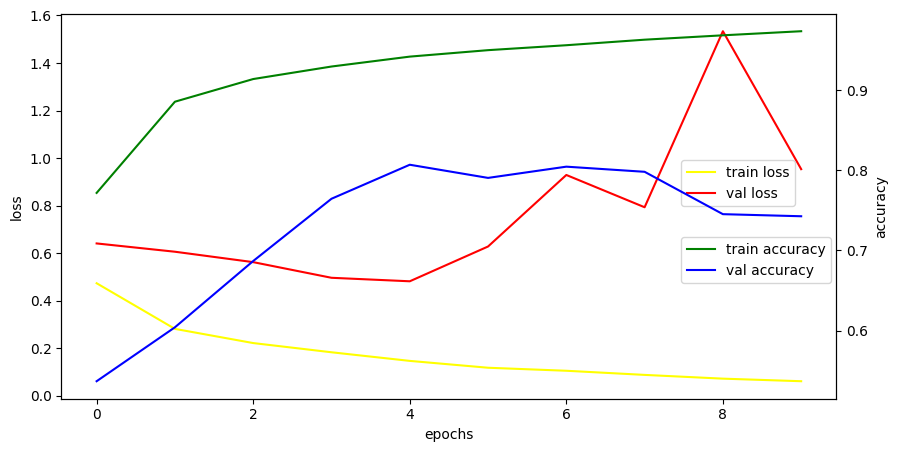

In [12]:
# hist.history.keys() # loss accuracy val_loss val_accuracy
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize = (10,5))
loss_ax.plot(hist.history.get('loss'), color='yellow', label='train loss')
loss_ax.plot(hist.history.get('val_loss'), color='red', label='val loss')
loss_ax.legend(loc=(0.8,0.5))
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history.get('accuracy'), color='green', label='train accuracy')
acc_ax.plot(hist.history.get('val_accuracy'), color='blue', label='val accuracy')
acc_ax.legend(loc=(0.8,0.3))
acc_ax.set_ylabel('accuracy')
plt.show()

# 12. 모델 평가하기

In [14]:
# pad_sequences 'post' : 75.81%
# pad_sequences 'pre' : 80.19%
# MY_LENGTH=178: 83.89%
loss, acc = model.evaluate(X_test, y_test)
print('정확도 :', acc)

782/782 [==============================] - 10s 13ms/step - loss: 0.9995 - accuracy: 0.7198
정확도 : 0.7198399901390076


In [15]:
# 혼동행렬, recall, precision을 위한 yhat
yhat = (model.predict(X_test, 
                      verbose=0) > 0.5).astype(np.int16).reshape(-1)
yhat

array([1, 0, 1, ..., 0, 0, 1], dtype=int16)

# 13. 모델 사용하기

In [18]:
review = """The movie was really exciting, 
and I watched it throughout the movie hoping it wouldn't end without 
watching the clock. I strongly recommend it. 
It was even more interesting thinking that it could happen in real life. 
The main character was handsome and acted well, so my eyes were happy, 
and the story was fun @_@ㅠ.ㅠ""".lower()
import re
review = re.sub('[^a-zA-Z\'\s]', '', review)
review = review.split() # 단어 list
review = [1] + [word_to_id.get(word, -1)+3 for word in review]
print(review, len(review))

[1, 4, 20, 16, 66, 1127, 5, 13, 296, 12, 469, 4, 20, 1383, 12, 586, 130, 209, 149, 4, 5431, 13, 2303, 386, 12, 12, 16, 60, 53, 221, 536, 15, 12, 100, 593, 11, 147, 113, 4, 293, 109, 16, 2252, 5, 917, 73, 38, 61, 523, 71, 654, 5, 4, 65, 16, 253] 56


In [19]:
input_data = pad_sequences([review],
                      padding='pre',
                      truncating='pre',
                      maxlen=MY_LENGTH)
input_data

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    1,    4,   20,   16,   66, 1127,    5,   13,  296,
          12,  469,    4,   20, 1383,   12,  586,  130,  209,  149,    4,
        5431,   13, 2303,  386,   12,   12,   16,   60,   53,  221,  536,
          15,   12,  100,  593,   11,  147,  113,    4,  293,  109,   16,
        2252,    5,  917,   73,   38,   61,  523,   71,  654,    5,    4,
          65,   16,  253]])

In [20]:
result = (model.predict(input_data)>0.5).astype('int8').reshape(-1)
result

1/1 [==============================] - 0s 25ms/step


array([1, 0], dtype=int8)